# IMPORTAÇÕES DE BIBLIOTECAS E CONFIGURAÇÕES VISUAIS


In [90]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score

In [91]:
# Armazenar e ler o dataframe
dados = pd.read_csv('/content/df_telecom_processado.csv')
dados.head()

,id_cliente,evasao,genero,cidadao_senior,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,multiplas_linhas,tipo_servico_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_online,metodo_pagamento,cobranca_mensal,cobranca_total,Contas_Diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,1,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,1,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,1,Não,Fibra óptica,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,1,Não,Fibra óptica,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,1,Não,Fibra óptica,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


#TRATAMENTO DE DADOS

In [92]:
dados = dados.drop(columns=['id_cliente'], axis=1)

In [93]:
# Tratar coluna genero
dados['genero'] = dados['genero'].replace({'Feminino':0, 'Masculino':1})
dados.head()

/tmp/ipykernel_671/4145245344.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados['genero'] = dados['genero'].replace({'Feminino':0, 'Masculino':1})


,evasao,genero,cidadao_senior,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,multiplas_linhas,tipo_servico_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_online,metodo_pagamento,cobranca_mensal,cobranca_total,Contas_Diarias
0,Não,0,0,Sim,Sim,9,1,Não,DSL,0,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,Não,1,0,Não,Não,9,1,Sim,DSL,0,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,Sim,1,0,Não,Não,4,1,Não,Fibra óptica,0,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,Sim,1,1,Sim,Não,13,1,Não,Fibra óptica,0,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,Sim,0,1,Sim,Não,3,1,Não,Fibra óptica,0,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


In [94]:

print(dados.apply(pd.Series.unique))

evasao                                                          [Não, Sim]
genero                                                              [0, 1]
cidadao_senior                                                      [0, 1]
possui_parceiro                                                 [Sim, Não]
possui_dependentes                                              [Sim, Não]
meses_contrato           [9, 4, 13, 3, 71, 63, 7, 65, 54, 72, 5, 56, 34...
servico_telefone                                                    [1, 0]
multiplas_linhas                       [Não, Sim, Sem serviço de telefone]
tipo_servico_internet                             [DSL, Fibra óptica, Não]
seguranca_online                                                    [0, 1]
backup_online                                                       [1, 0]
protecao_dispositivo                   [Não, Sim, Sem serviço de internet]
suporte_tecnico                        [Sim, Não, Sem serviço de internet]
streaming_tv             

In [95]:
lista = list(dados.columns)
colunas_categoricas = lista[7:18]
print(colunas_categoricas)
pd.get_dummies(dados, columns=colunas_categoricas)

['multiplas_linhas', 'tipo_servico_internet', 'seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes', 'tipo_contrato', 'fatura_online', 'metodo_pagamento']


,evasao,genero,cidadao_senior,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,cobranca_mensal,cobranca_total,Contas_Diarias,...,streaming_filmes_Sim,tipo_contrato_Anual,tipo_contrato_Dois anos,tipo_contrato_Mensal,fatura_online_Não,fatura_online_Sim,metodo_pagamento_Cartão de crédito (automático),metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque enviado,metodo_pagamento_Transferência bancária (automática)
0,Não,0,0,Sim,Sim,9,1,65.60,593.30,2.186667,...,False,True,False,False,False,True,False,False,True,False
1,Não,1,0,Não,Não,9,1,59.90,542.40,1.996667,...,True,False,False,True,True,False,False,False,True,False
2,Sim,1,0,Não,Não,4,1,73.90,280.85,2.463333,...,False,False,False,True,False,True,False,True,False,False
3,Sim,1,1,Sim,Não,13,1,98.00,1237.85,3.266667,...,True,False,False,True,False,True,False,True,False,False
4,Sim,0,1,Sim,Não,3,1,83.90,267.40,2.796667,...,False,False,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Não,0,0,Não,Não,13,1,55.15,742.90,1.838333,...,False,True,False,False,True,False,False,False,True,False
7028,Sim,1,0,Sim,Não,22,1,85.10,1873.70,2.836667,...,True,False,False,True,False,True,False,True,False,False
7029,Não,1,0,Não,Não,2,1,50.30,92.75,1.676667,...,False,False,False,True,False,True,False,False,True,False
7030,Não,1,0,Sim,Sim,67,1,67.85,4627.65,2.261667,...,True,False,True,False,True,False,False,False,True,False


In [96]:
# Transformando variáveis categóricas para numéricas
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown = 'ignore'),
    colunas_categoricas),
    remainder='passthrough')
dados = one_hot_enc.fit_transform(dados)
dados = pd.DataFrame(dados, columns=one_hot_enc.get_feature_names_out())
dados

,onehotencoder__multiplas_linhas_Não,onehotencoder__multiplas_linhas_Sem serviço de telefone,onehotencoder__multiplas_linhas_Sim,onehotencoder__tipo_servico_internet_DSL,onehotencoder__tipo_servico_internet_Fibra óptica,onehotencoder__tipo_servico_internet_Não,onehotencoder__seguranca_online_0,onehotencoder__seguranca_online_1,onehotencoder__backup_online_0,onehotencoder__backup_online_1,...,remainder__evasao,remainder__genero,remainder__cidadao_senior,remainder__possui_parceiro,remainder__possui_dependentes,remainder__meses_contrato,remainder__servico_telefone,remainder__cobranca_mensal,remainder__cobranca_total,remainder__Contas_Diarias
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,Não,0,0,Sim,Sim,9,1,65.6,593.3,2.186667
1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,Não,1,0,Não,Não,9,1,59.9,542.4,1.996667
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,Sim,1,0,Não,Não,4,1,73.9,280.85,2.463333
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Sim,1,1,Sim,Não,13,1,98.0,1237.85,3.266667
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,Sim,0,1,Sim,Não,3,1,83.9,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Não,0,0,Não,Não,13,1,55.15,742.9,1.838333
7028,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,Sim,1,0,Sim,Não,22,1,85.1,1873.7,2.836667
7029,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,Não,1,0,Não,Não,2,1,50.3,92.75,1.676667
7030,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Não,1,0,Sim,Sim,67,1,67.85,4627.65,2.261667


# VERIFICAÇÃO DA PROPORÇÃO DE EVASÃO

In [97]:
dados.value_counts('remainder__evasao')

,count
remainder__evasao,
Não,5163
Sim,1869


# MATRIZ DE CORRELAÇÃO

In [98]:
# verifica correlação com a variável de evasão
# Converter 'remainder__evasao' e outras colunas binárias para numérico
dados['remainder__evasao'] = dados['remainder__evasao'].replace({'Não': 0, 'Sim': 1})
dados['remainder__possui_parceiro'] = dados['remainder__possui_parceiro'].replace({'Não': 0, 'Sim': 1})
dados['remainder__possui_dependentes'] = dados['remainder__possui_dependentes'].replace({'Não': 0, 'Sim': 1})

corr = dados.corr()['remainder__evasao']
corr

/tmp/ipykernel_671/276182357.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados['remainder__evasao'] = dados['remainder__evasao'].replace({'Não': 0, 'Sim': 1})
/tmp/ipykernel_671/276182357.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados['remainder__possui_parceiro'] = dados['remainder__possui_parceiro'].replace({'Não': 0, 'Sim': 1})
/tmp/ipykernel_671/276182357.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `

,remainder__evasao
onehotencoder__multiplas_linhas_Não,-0.032654
onehotencoder__multiplas_linhas_Sem serviço de telefone,-0.011691
onehotencoder__multiplas_linhas_Sim,0.040033
onehotencoder__tipo_servico_internet_DSL,-0.124141
onehotencoder__tipo_servico_internet_Fibra óptica,0.307463
onehotencoder__tipo_servico_internet_Não,-0.227578
onehotencoder__seguranca_online_0,0.171270
onehotencoder__seguranca_online_1,-0.171270
onehotencoder__backup_online_0,0.082307
onehotencoder__backup_online_1,-0.082307


In [99]:
# Correlação maior que 3
corr[corr > 0.3]

,remainder__evasao
onehotencoder__tipo_servico_internet_Fibra óptica,0.307463
onehotencoder__suporte_tecnico_Não,0.336877
onehotencoder__tipo_contrato_Mensal,0.404565
onehotencoder__metodo_pagamento_Cheque eletrônico,0.301455
remainder__evasao,1.000000


In [100]:
# Correlação menor que -0.3
corr[corr < -0.3]

,remainder__evasao
onehotencoder__tipo_contrato_Dois anos,-0.301552
remainder__meses_contrato,-0.354049


# RELAÇÃO ENTRE VARIÁVEIS IMPORTANTES E EVASÃO

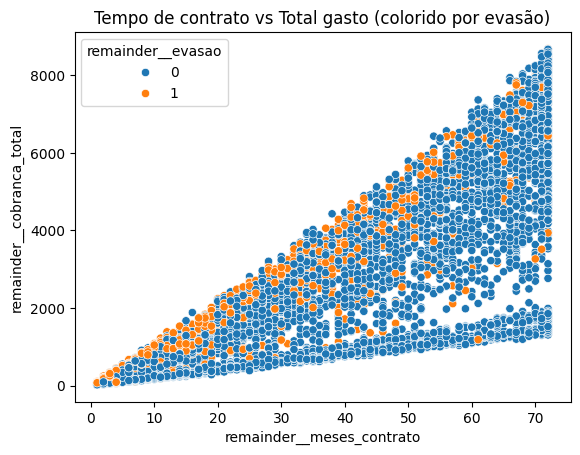

In [101]:
# Tempo de contrato vs Total gasto, colorindo por Churn
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='remainder__meses_contrato', y='remainder__cobranca_total', hue='remainder__evasao', data=dados)
plt.title("Tempo de contrato vs Total gasto (colorido por evasão)")
plt.show()

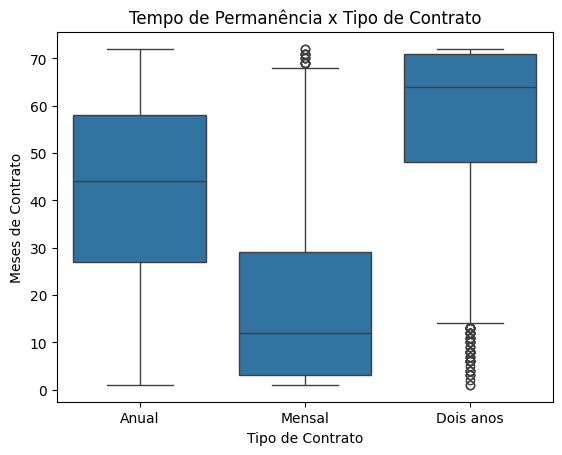

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reconstruct 'tipo_contrato' from one-hot encoded columns for plotting
contract_type_cols = [
    'onehotencoder__tipo_contrato_Anual',
    'onehotencoder__tipo_contrato_Dois anos',
    'onehotencoder__tipo_contrato_Mensal'
]

def get_contract_type(row):
    if row['onehotencoder__tipo_contrato_Anual'] == 1.0:
        return 'Anual'
    elif row['onehotencoder__tipo_contrato_Dois anos'] == 1.0:
        return 'Dois anos'
    elif row['onehotencoder__tipo_contrato_Mensal'] == 1.0:
        return 'Mensal'
    return 'Outro'

dados['reconstructed_tipo_contrato'] = dados.apply(get_contract_type, axis=1)

sns.boxplot(x='reconstructed_tipo_contrato',
               y='remainder__meses_contrato',
               data=dados)

plt.title("Tempo de Permanência x Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Meses de Contrato")
plt.show()

Observa-se que clientes com menor tempo de contrato apresentam maior índice de evasão. Isso indica que os primeiros meses são decisivos para a retenção do cliente.

# REMOÇÃO DE COLUNAS IRRELEVANTES

In [103]:

dados.columns

Index(['onehotencoder__multiplas_linhas_Não',
       'onehotencoder__multiplas_linhas_Sem serviço de telefone',
       'onehotencoder__multiplas_linhas_Sim',
       'onehotencoder__tipo_servico_internet_DSL',
       'onehotencoder__tipo_servico_internet_Fibra óptica',
       'onehotencoder__tipo_servico_internet_Não',
       'onehotencoder__seguranca_online_0',
       'onehotencoder__seguranca_online_1', 'onehotencoder__backup_online_0',
       'onehotencoder__backup_online_1',
       'onehotencoder__protecao_dispositivo_Não',
       'onehotencoder__protecao_dispositivo_Sem serviço de internet',
       'onehotencoder__protecao_dispositivo_Sim',
       'onehotencoder__suporte_tecnico_Não',
       'onehotencoder__suporte_tecnico_Sem serviço de internet',
       'onehotencoder__suporte_tecnico_Sim', 'onehotencoder__streaming_tv_Não',
       'onehotencoder__streaming_tv_Sem serviço de internet',
       'onehotencoder__streaming_tv_Sim',
       'onehotencoder__streaming_filmes_Não',
       

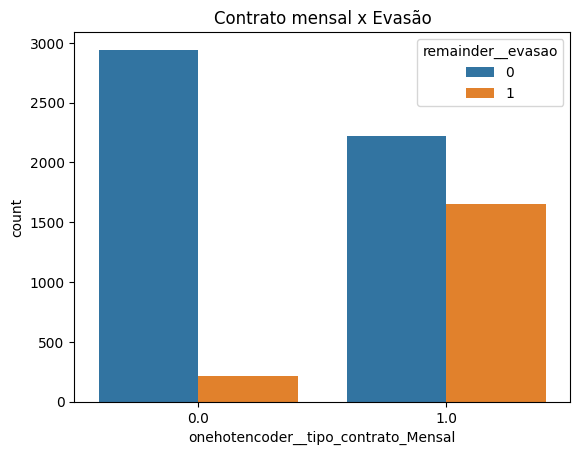

In [104]:

sns.countplot(x='onehotencoder__tipo_contrato_Mensal', hue='remainder__evasao', data=dados)
plt.title("Contrato mensal x Evasão")
plt.show()

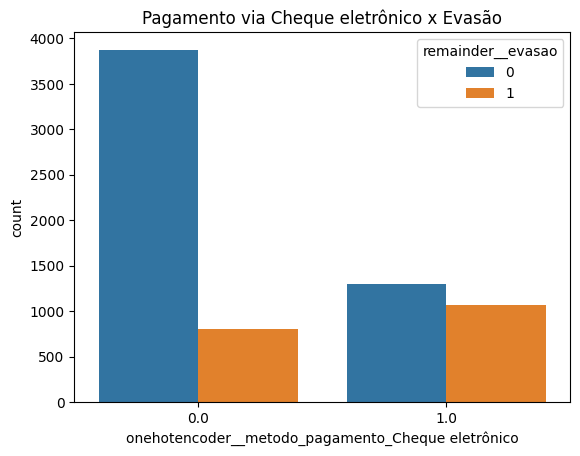

In [105]:
sns.countplot(x='onehotencoder__metodo_pagamento_Cheque eletrônico', hue='remainder__evasao', data=dados)
plt.title("Pagamento via Cheque eletrônico x Evasão")
plt.show()

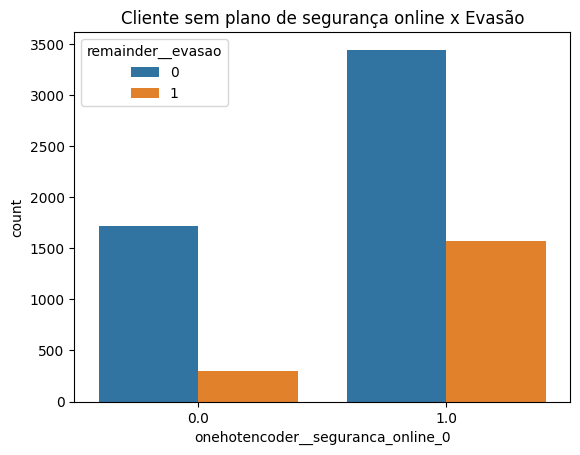

In [106]:
sns.countplot(x='onehotencoder__seguranca_online_0', hue='remainder__evasao', data=dados)
plt.title("Cliente sem plano de segurança online x Evasão")
plt.show()

# ENCODING DAS VARIÁVEIS CATEGÓRICAS

In [107]:
# Definindo variável dependente e explicativas
# X = dados.drop(columns='remainder__evasao')
# y = dados['remainder__evasao']
# Moved to cell TC-aNJMBxiAt to resolve NameError

# SEPARAÇÃO TREINO E TESTE

In [108]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Definindo variável dependente e explicativas
# Excluir a coluna 'reconstructed_tipo_contrato' pois é uma string e não deve ser usada diretamente no modelo numérico
X = dados.drop(columns=['remainder__evasao', 'reconstructed_tipo_contrato'])
y = dados['remainder__evasao']

# Separar os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo base - DummyClassifier
model_dummy = DummyClassifier()
model_dummy.fit(X_train, y_train)

acuracia_dummy = model_dummy.score(X_test, y_test)
print(f'Acurácia do modelo DummyClassifier: {acuracia_dummy:.2%}')

Acurácia do modelo DummyClassifier: 73.65%


In [109]:
# Modelo KNN - KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

acuracia_knn = model_knn.score(X_test, y_test)
print(f'Acurácia do modelo KNeighborsClassifier: {acuracia_knn:.2%}')

Acurácia do modelo KNeighborsClassifier: 76.21%


# NORMALIZAÇÃO (PARA REGRESSÃO LOGÍSTICA)

In [110]:
# Modelo Regressão Logística precisa normalizar dados
# Normaliza dados
from sklearn.preprocessing import StandardScaler

normaliza = StandardScaler()
X_train_normalizado = normaliza.fit_transform(X_train)
X_test_normalizado = normaliza.transform(X_test)

# Treina o modelo com os dados normalizados
# Modelo Regressão
from sklearn.linear_model import LogisticRegression

model_logreg = LogisticRegression(max_iter=1000)
model_logreg.fit(X_train_normalizado, y_train)

acuracia_logreg = model_logreg.score(X_test_normalizado, y_test)
print(f'Acurácia do modelo LogisticRegression: {acuracia_logreg:.2%}')


Acurácia do modelo LogisticRegression: 80.28%


# MODELO RANDOM FOREST (SEM NORMALIZAÇÃO)

In [111]:
# Modelo RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

model_rfc = RandomForestClassifier()
model_rfc.fit(X_train, y_train)

acuracia_rfc = model_rfc.score(X_test, y_test)
print(f'Acurácia do modelo RandomForestClassifier: {acuracia_rfc:.2%}')

Acurácia do modelo RandomForestClassifier: 78.63%


Acurácia do modelo DecisionTreeClassifier: 72.04%


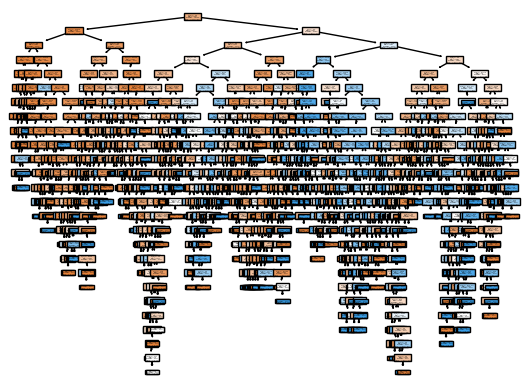

In [134]:
# Modelo DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

model_tree = DecisionTreeClassifier() # sem max_leaf_nodes, deixar o modelo complexo demais por questões didáticas
model_tree.fit(X_train, y_train)

acuracia_tree = model_tree.score(X_test, y_test)
print(f'Acurácia do modelo DecisionTreeClassifier: {acuracia_tree:.2%}')


plot_tree(model_tree, proportion=True, filled=True)
plt.show()



In [113]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

model_tree = DecisionTreeClassifier(
    max_depth=4,              # limita profundidade
    min_samples_leaf=20,      # evita folhas muito pequenas
    random_state=42
)

model_tree.fit(X_train, y_train)

acuracia_treino = model_tree.score(X_train, y_train)
acuracia_teste = model_tree.score(X_test, y_test)

print(f'Acurácia TREINO: {acuracia_treino:.2%}')
print(f'Acurácia TESTE: {acuracia_teste:.2%}')

Acurácia TREINO: 79.93%
Acurácia TESTE: 78.58%


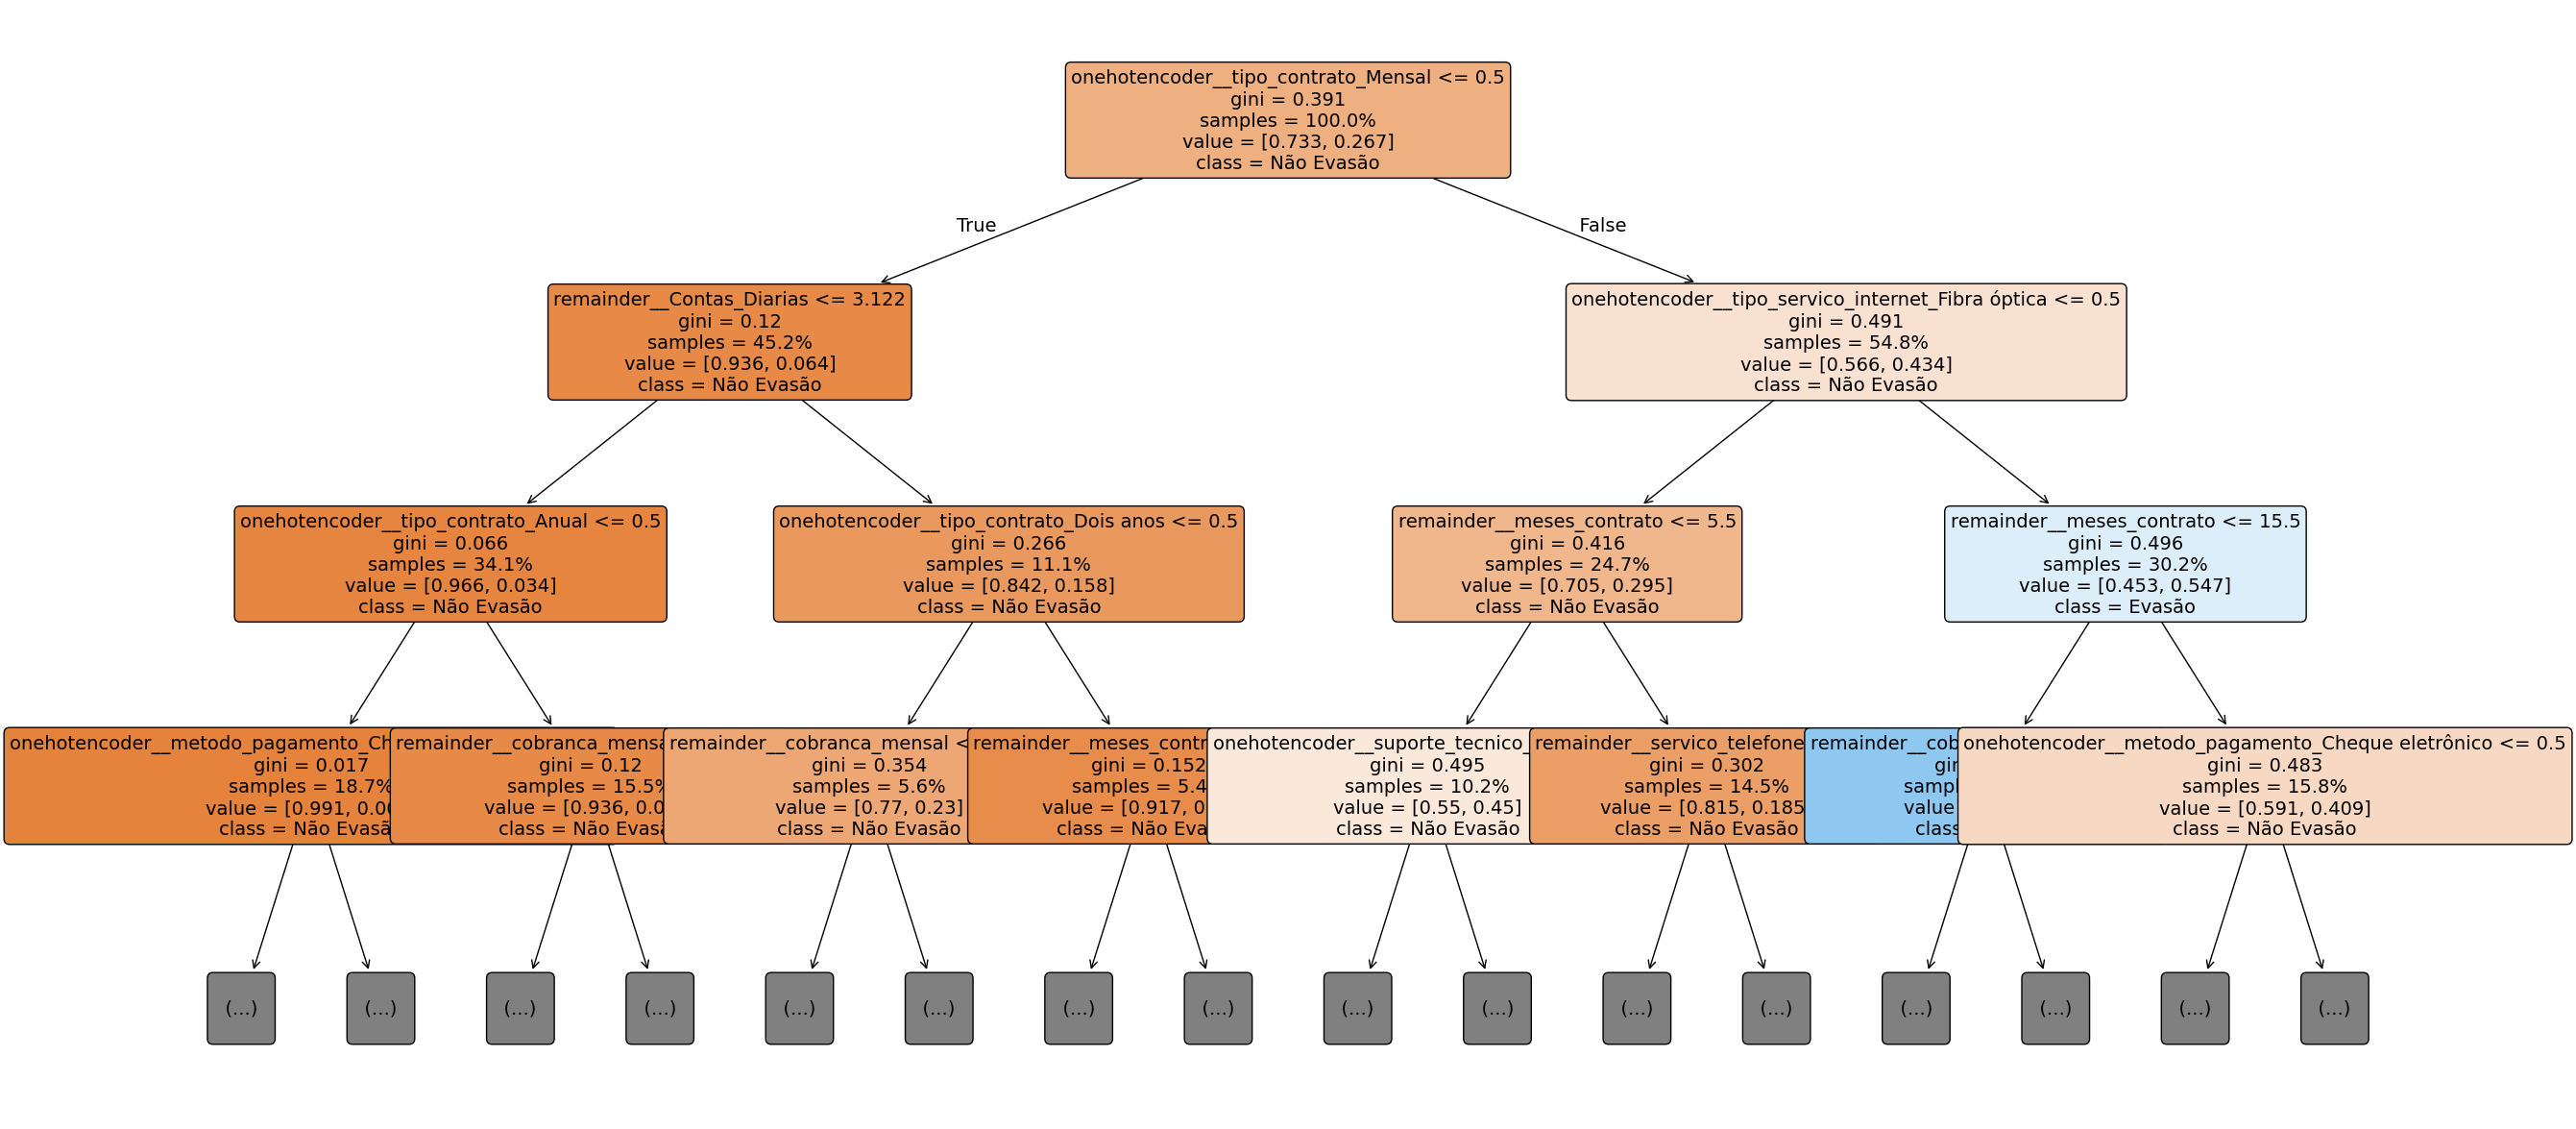

In [114]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30,15))  # aumenta bastante o tamanho da figura

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=['Não Evasão', 'Evasão'],
    filled=True,
    proportion=True,
    rounded=True,
    max_depth=3,
    fontsize=14  # aumenta o tamanho da fonte
)

plt.show()

O modelo de árvore de decisão segmenta os clientes a partir das variáveis mais importantes para prever a evasão. Cada divisão representa uma regra baseada nos dados, facilitando a interpretação dos principais critérios que levam ao cancelamento.

# IMPORTÂNCIA DAS VARIÁVEIS (Random Forest)

In [115]:
# Modelo RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

model_rfc = RandomForestClassifier()
model_rfc.fit(X_train, y_train)

acuracia_rfc = model_rfc.score(X_test, y_test)
print(f'Acurácia do modelo RandomForestClassifier: {acuracia_rfc:.2%}')


Acurácia do modelo RandomForestClassifier: 77.87%


# ANÁLISE DE OVERFITTING

In [116]:
'''
  Avaliar:
    Acurácia
    Precisão
    Recall
    F1-score
    Matriz de confusão
'''
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Acurácia: 73.65%
Precisão: 0.00%
Recall: 0.00%
F1-score: 0.00%
Erro UndefinedMetricWarning aparece pois o modelo previu somente um valor
      então algumas métricas ficam indefinidas.
Matriz de confusão:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


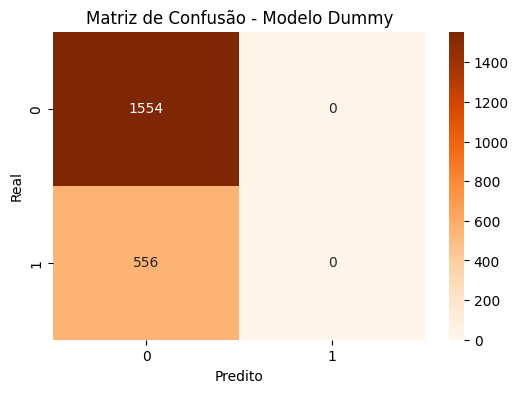

In [117]:
# Avaliar modelo base - DummyClassifier
y_pred_dummy = (model_dummy.predict(X_test))

print(f'Acurácia: {accuracy_score(y_test, y_pred_dummy):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_dummy):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_dummy):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_dummy):.2%}')
print('''Erro UndefinedMetricWarning aparece pois o modelo previu somente um valor
      então algumas métricas ficam indefinidas.''')
print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_dummy)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo Dummy")

plt.show()

Acurácia: 76.21%
Precisão: 55.77%
Recall: 46.94%
F1-score: 50.98%
Matriz de confusão:


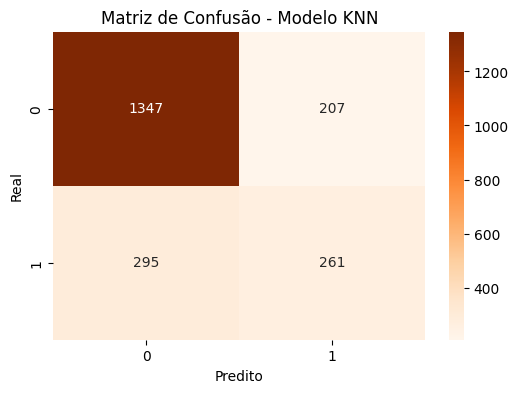

In [118]:
# Avaliar modelo KNeighborsClassifier
y_pred_knn = model_knn.predict(X_test)

print(f'Acurácia: {accuracy_score(y_test, y_pred_knn):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_knn):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_knn):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_knn):.2%}')

print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_knn)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo KNN")

plt.show()

Acurácia: 80.28%
Precisão: 64.17%
Recall: 57.01%
F1-score: 60.38%
Matriz de confusão:


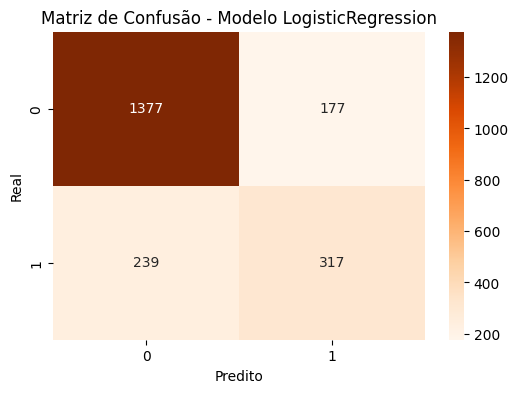

In [119]:
# Avaliar modelo LogisticRegression
# Probabilidades previstas
y_probs = model_logreg.predict_proba(X_test_normalizado)[:, 1]

# Ajustando o threshold
threshold = 0.3  # exemplo: mais baixo para aumentar recall
y_pred_logreg = (y_probs >= threshold).astype(int)

y_pred_logreg = model_logreg.predict(X_test_normalizado)

print(f'Acurácia: {accuracy_score(y_test, y_pred_logreg):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_logreg):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_logreg):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_logreg):.2%}')

print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_logreg)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo LogisticRegression")

plt.show()

Acurácia: 78.58%
Precisão: 61.50%
Recall: 50.00%
F1-score: 55.16%
Matriz de confusão:


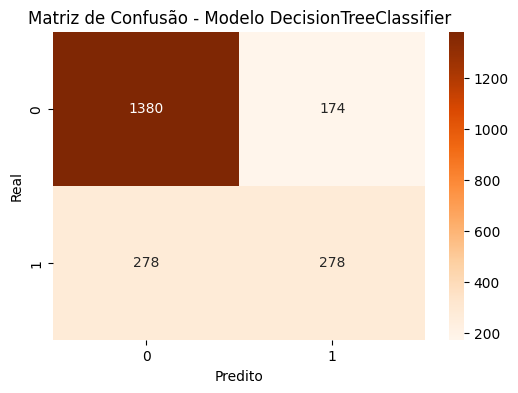

In [120]:
# Avaliar modelo DecisionTreeClassifier
y_pred_tree = model_tree.predict(X_test)

print(f'Acurácia: {accuracy_score(y_test, y_pred_tree):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_tree):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_tree):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_tree):.2%}')

print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_tree)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo DecisionTreeClassifier")

plt.show()

Acurácia: 77.87%
Precisão: 59.49%
Recall: 50.18%
F1-score: 54.44%
Matriz de confusão:


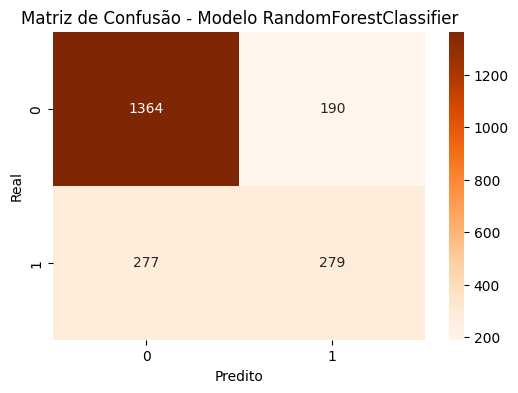

In [121]:
# Avaliar modelo RandomForestClassifier
y_pred_rfc = model_rfc.predict(X_test)

print(f'Acurácia: {accuracy_score(y_test, y_pred_rfc):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_rfc):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_rfc):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_rfc):.2%}')

print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_rfc)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo RandomForestClassifier")

plt.show()

In [122]:
import pandas as pd

# Definir as métricas de desempenho para cada modelo
dese_dummy = {
    'Modelo': 'Dummy',
    'Acurácia': accuracy_score(y_test, y_pred_dummy),
    'Precisão': precision_score(y_test, y_pred_dummy, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dummy, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_dummy, zero_division=0)
}

dese_knn = {
    'Modelo': 'KNN',
    'Acurácia': accuracy_score(y_test, y_pred_knn),
    'Precisão': precision_score(y_test, y_pred_knn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_knn, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_knn, zero_division=0)
}

dese_logreg = {
    'Modelo': 'Regressão Logística',
    'Acurácia': accuracy_score(y_test, y_pred_logreg),
    'Precisão': precision_score(y_test, y_pred_logreg, zero_division=0),
    'Recall': recall_score(y_test, y_pred_logreg, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_logreg, zero_division=0)
}

dese_tree = {
    'Modelo': 'Árvore de Decisão',
    'Acurácia': accuracy_score(y_test, y_pred_tree),
    'Precisão': precision_score(y_test, y_pred_tree, zero_division=0),
    'Recall': recall_score(y_test, y_pred_tree, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_tree, zero_division=0)
}

dese_rfc = {
    'Modelo': 'Random Forest',
    'Acurácia': accuracy_score(y_test, y_pred_rfc),
    'Precisão': precision_score(y_test, y_pred_rfc, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rfc, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_rfc, zero_division=0)
}

# Criar o DataFrame desempenho_geral
dese_geral_list = [dese_dummy, dese_knn, dese_logreg, dese_tree, dese_rfc]
dese_geral = pd.DataFrame(dese_geral_list)

# Ajustar índice para melhorar visualização
dese_geral = dese_geral.set_index('Modelo')

# Exibir tabela estilizada
styled_table = (
    dese_geral.style
        .set_caption("Comparação Geral de Desempenho dos Modelos (%)")
        .format("{:.2%}") # Formatar como porcentagem
        .background_gradient(cmap="Oranges", axis=0)
        .set_properties(**{
            'text-align': 'center',
            'font-size': '14px',
            'padding': '10px'
        })
        .set_table_styles([
            {'selector': 'th',
             'props': [
                 ('font-size', '14px'),
                 ('text-align', 'center'),
                 ('padding', '10px')
             ]}
        ])
)

styled_table

,Acurácia,Precisão,Recall,F1-score
Modelo,,,,
Dummy,73.65%,0.00%,0.00%,0.00%
KNN,76.21%,55.77%,46.94%,50.98%
Regressão Logística,80.28%,64.17%,57.01%,60.38%
Árvore de Decisão,78.58%,61.50%,50.00%,55.16%
Random Forest,77.87%,59.49%,50.18%,54.44%


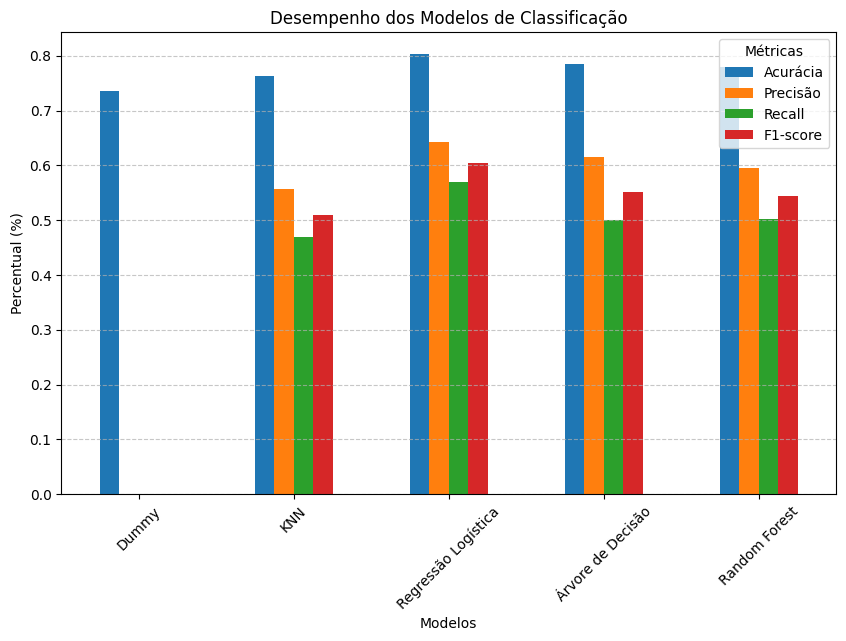

In [123]:
# Plotando gráfico comparativo
dese_geral.plot(kind='bar', figsize=(10,6))
plt.title("Desempenho dos Modelos de Classificação")
plt.ylabel("Percentual (%)")
plt.xlabel("Modelos")
plt.xticks(rotation=45)
plt.legend(title="Métricas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

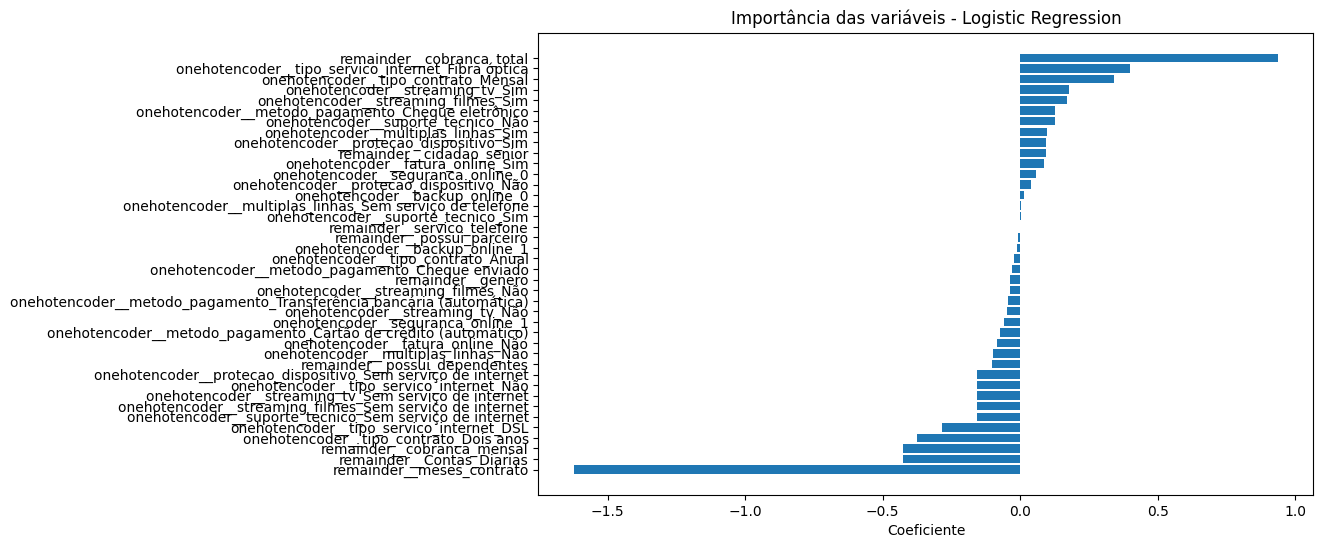

In [124]:
import pandas as pd
import matplotlib.pyplot as plt

coef = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': model_logreg.coef_[0]
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coef['Variável'], coef['Importância'])
plt.title("Importância das variáveis - Logistic Regression")
plt.xlabel("Coeficiente")
plt.gca().invert_yaxis()
plt.show()


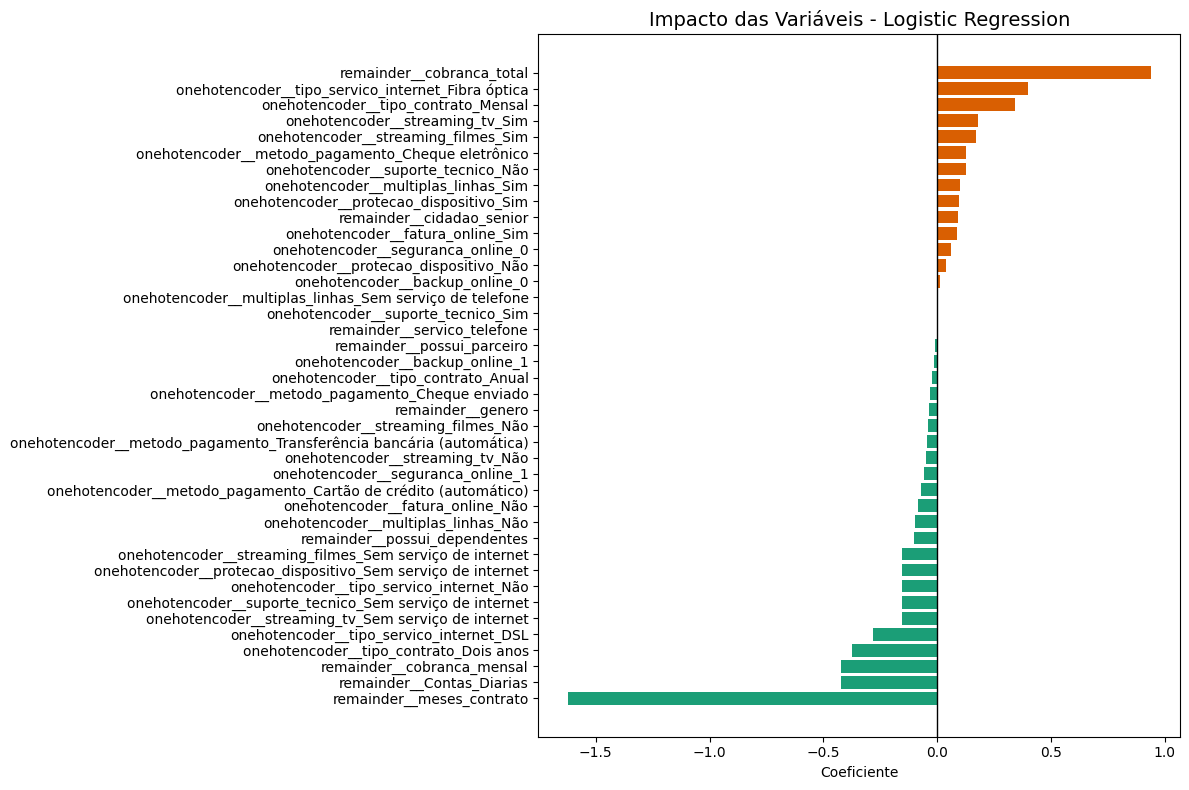

In [125]:
import numpy as np

coef = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': model_logreg.coef_[0]
}).sort_values(by='Importância')

plt.figure(figsize=(12,8))

cores = ['#d95f02' if x > 0 else '#1b9e77' for x in coef['Importância']]

plt.barh(coef['Variável'], coef['Importância'], color=cores)
plt.axvline(0, color='black', linewidth=1)

plt.title("Impacto das Variáveis - Logistic Regression", fontsize=14)
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

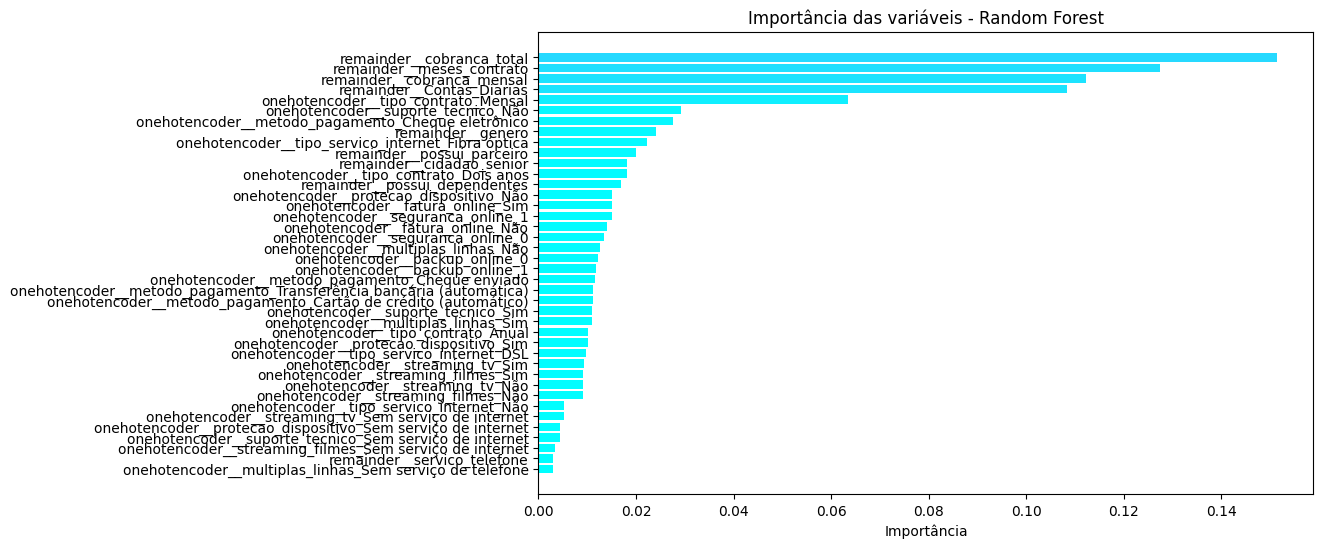

In [126]:
importances = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': model_rfc.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importances['Variável'], importances['Importância'],
         color=plt.cm.cool(importances['Importância']))
plt.title("Importância das variáveis - Random Forest")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.show()

## Análise Estatística e Interpretação dos Resultados

### Exame detalhado das métricas obtidas e discussão dos padrões observados nos dados.


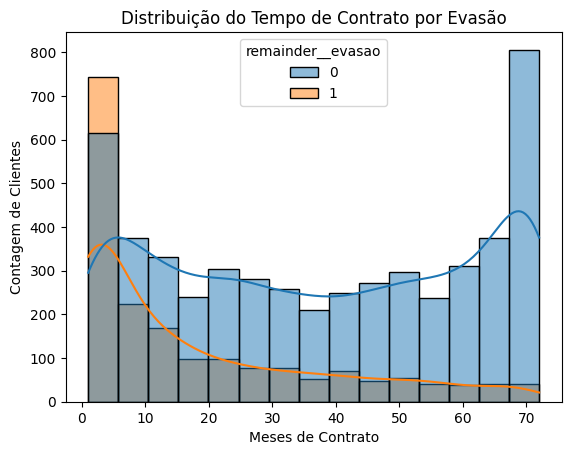

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=dados, x='remainder__meses_contrato', hue='remainder__evasao', kde=True)
plt.title('Distribuição do Tempo de Contrato por Evasão')
plt.xlabel('Meses de Contrato')
plt.ylabel('Contagem de Clientes')
plt.show()

O gráfico apresenta a distribuição do tempo de contrato dos clientes, em meses, associada à ocorrência de evasão. Observa-se que a maior concentração de evasão ocorre nos primeiros meses de contrato, indicando que clientes com pouco tempo de relacionamento com a empresa possuem maior probabilidade de cancelar o serviço. À medida que o tempo de contrato aumenta, a frequência de evasão tende a diminuir, demonstrando que clientes com maior tempo de permanência apresentam maior fidelidade. Dessa forma, o gráfico evidencia que o início do contrato representa um período mais crítico para retenção de clientes, sendo importante a adoção de estratégias voltadas à fidelização nesse estágio inicial.



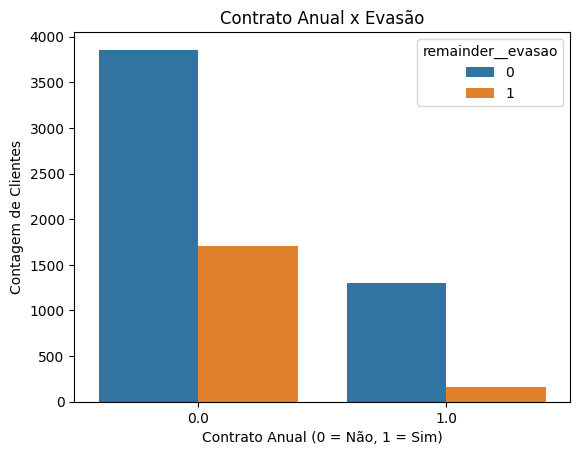

In [128]:
sns.countplot(x='onehotencoder__tipo_contrato_Anual', hue='remainder__evasao', data=dados)
plt.title("Contrato Anual x Evasão")
plt.xlabel("Contrato Anual (0 = Não, 1 = Sim)")
plt.ylabel("Contagem de Clientes")
plt.show()

O gráfico apresenta a relação entre a existência de contrato anual e a evasão de clientes. Observa-se que a maioria dos clientes que não possuem contrato anual (0) apresenta maior quantidade de evasão quando comparados aos clientes que possuem contrato anual (1). Por outro lado, clientes com contrato anual demonstram menor índice de evasão, indicando maior tendência de permanência no serviço. Dessa forma, o tipo de contrato pode ser considerado um fator relevante para a retenção de clientes, sugerindo que contratos de maior duração contribuem para reduzir a evasão.

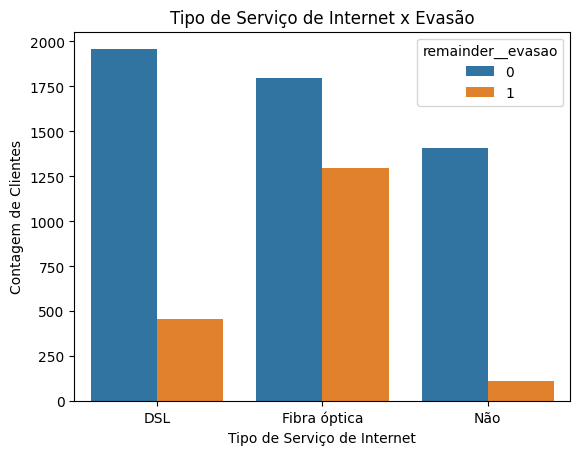

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reconstruct 'tipo_servico_internet' from one-hot encoded columns for plotting
internet_service_cols = [
    'onehotencoder__tipo_servico_internet_DSL',
    'onehotencoder__tipo_servico_internet_Fibra óptica',
    'onehotencoder__tipo_servico_internet_Não'
]

def get_internet_service_type(row):
    if row['onehotencoder__tipo_servico_internet_DSL'] == 1.0:
        return 'DSL'
    elif row['onehotencoder__tipo_servico_internet_Fibra óptica'] == 1.0:
        return 'Fibra óptica'
    elif row['onehotencoder__tipo_servico_internet_Não'] == 1.0:
        return 'Não'
    return 'Outro'

dados['reconstructed_tipo_servico_internet'] = dados.apply(get_internet_service_type, axis=1)

sns.countplot(x='reconstructed_tipo_servico_internet', hue='remainder__evasao', data=dados)
plt.title("Tipo de Serviço de Internet x Evasão")
plt.xlabel("Tipo de Serviço de Internet")
plt.ylabel("Contagem de Clientes")
plt.show()

O gráfico apresenta a relação entre o tipo de serviço de internet e a evasão de clientes. Observa-se que clientes que utilizam fibra óptica apresentam maior quantidade de evasão em comparação aos clientes que utilizam DSL. Já os clientes que não possuem serviço de internet apresentam menor ocorrência de evasão. Esses resultados indicam que o tipo de serviço contratado pode influenciar no comportamento de permanência ou cancelamento dos clientes.


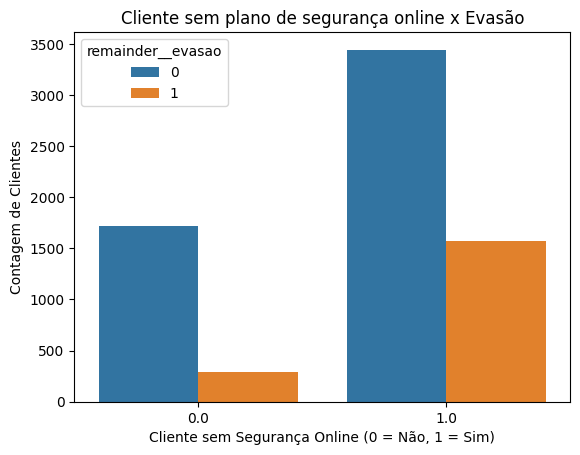

In [130]:
sns.countplot(x='onehotencoder__seguranca_online_0', hue='remainder__evasao', data=dados)
plt.title("Cliente sem plano de segurança online x Evasão")
plt.xlabel("Cliente sem Segurança Online (0 = Não, 1 = Sim)")
plt.ylabel("Contagem de Clientes")
plt.show()

O gráfico mostra a relação entre a ausência de plano de segurança online e a evasão de clientes. Observa-se que clientes que não possuem plano de segurança online apresentam maior quantidade de evasão em comparação aos que possuem esse serviço. Esse resultado sugere que a oferta de serviços adicionais, como segurança online, pode contribuir para aumentar a retenção e reduzir o cancelamento de clientes.



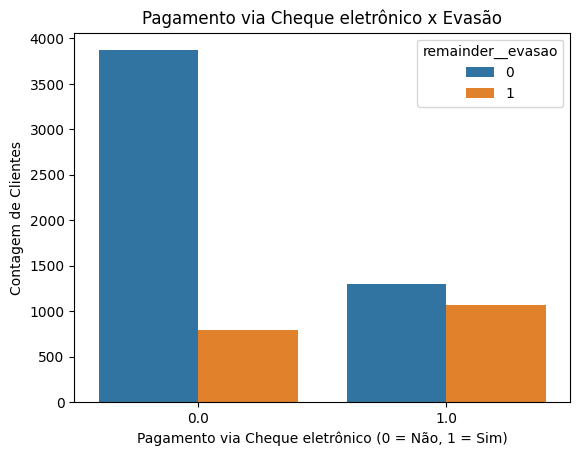

In [131]:
sns.countplot(x='onehotencoder__metodo_pagamento_Cheque eletrônico', hue='remainder__evasao', data=dados)
plt.title("Pagamento via Cheque eletrônico x Evasão")
plt.xlabel("Pagamento via Cheque eletrônico (0 = Não, 1 = Sim)")
plt.ylabel("Contagem de Clientes")
plt.show()

A forma de pagamento demonstra relação com a evasão. Clientes que utilizam cheque eletrônico apresentam proporção mais elevada de cancelamento quando comparados aos demais meios de pagamento.

Embora o número absoluto de clientes seja maior entre os que não utilizam cheque eletrônico, a taxa relativa de evasão é superior entre os que utilizam esse método, indicando possível associação com perfil comportamental ou fricções no processo de cobrança.

Implicações estratégicas

A empresa pode incentivar a migração para métodos como débito automático ou cartão de crédito, além de investigar possíveis dificuldades associadas ao cheque eletrônico.

Essa variável também mostra potencial explicativo relevante dentro de modelos preditivos.

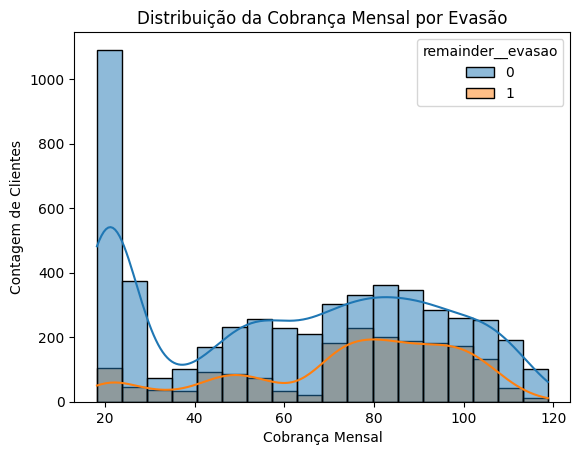

In [132]:
sns.histplot(data=dados, x='remainder__cobranca_mensal', hue='remainder__evasao', kde=True)
plt.title('Distribuição da Cobrança Mensal por Evasão')
plt.xlabel('Cobrança Mensal')
plt.ylabel('Contagem de Clientes')
plt.show()

A análise da cobrança mensal indica um padrão claro entre valor pago e evasão. Clientes que permanecem concentram-se majoritariamente nas faixas de menor valor, especialmente entre 20 e 40. Em contrapartida, a evasão é mais frequente entre clientes com mensalidades intermediárias e elevadas, sobretudo entre 70 e 100.

Esse comportamento sugere que valores mais altos aumentam a probabilidade de cancelamento, possivelmente devido à maior sensibilidade ao preço ou percepção reduzida de custo-benefício.

Implicações estratégicas

A empresa pode direcionar ações de retenção para clientes com maior ticket médio, como ofertas personalizadas, benefícios adicionais ou revisão de planos intermediários.

Além disso, a cobrança mensal se destaca como variável relevante para modelos preditivos de churn.

# Relatório Final – Análise de Evasão de Clientes (Churn)  
## Projeto: Telecom X

---

## 1. Introdução

A evasão de clientes (churn) representa um dos principais desafios estratégicos no setor de telecomunicações, impactando diretamente a receita, a previsibilidade financeira e a sustentabilidade do negócio. Em mercados altamente competitivos, compreender os fatores que levam ao cancelamento de serviços é fundamental para desenvolver estratégias eficazes de retenção.

Este relatório apresenta os resultados da análise exploratória realizada sobre a base de dados da Telecom X, com o objetivo de identificar padrões comportamentais e variáveis críticas associadas à evasão de clientes.

---

## 2. Objetivo do Projeto

O objetivo central deste projeto é analisar os dados históricos dos clientes da Telecom X para:

- Identificar os principais fatores associados ao churn;
- Gerar insights estratégicos que apoiem a tomada de decisão;
- Contribuir para o desenvolvimento de ações preventivas de retenção;
- Demonstrar a aplicação prática de técnicas de análise de dados utilizando Python.

---

## 3. Metodologia

A condução do projeto foi estruturada em etapas organizadas, garantindo consistência analítica e confiabilidade nos resultados.

### 3.1 Coleta e compreensão dos dados

Foi utilizada uma base de dados contendo informações demográficas, contratuais e financeiras dos clientes, incluindo:

- Tempo de permanência (tenure);
- Tipo de contrato;
- Serviços contratados;
- Forma de pagamento;
- Valor mensal cobrado;
- Indicador de evasão (churn).

---

### 3.2 Tratamento e preparação dos dados

Para assegurar a qualidade da análise, foram realizadas as seguintes ações:

- Padronização dos nomes das colunas para o idioma português;
- Verificação e tratamento de valores ausentes;
- Conversão de variáveis categóricas para formato adequado;
- Validação da consistência dos tipos de dados.

---

### 3.3 Análise exploratória dos dados

Foram aplicadas estatísticas descritivas e visualizações gráficas para:

- Avaliar a proporção de clientes que cancelaram e que permaneceram;
- Comparar variáveis como tempo de contrato, tipo de plano e valor mensal;
- Identificar padrões e tendências associados à evasão.

---

## 4. Resultados da Análise

### 4.1 Distribuição da evasão

A análise evidenciou que uma parcela significativa da base apresentou cancelamento, reforçando a necessidade de estratégias direcionadas para retenção e monitoramento contínuo do comportamento dos clientes.

---

### 4.2 Tempo de contrato

Clientes com menor tempo de permanência demonstraram maior probabilidade de evasão. Esse resultado indica que os primeiros meses de relacionamento com a empresa representam um período crítico para fidelização e construção de valor percebido.

---

### 4.3 Tipo de contrato

Contratos mensais apresentaram maior taxa de evasão quando comparados a contratos anuais ou bienais. Esse padrão sugere que vínculos contratuais de maior duração contribuem para a estabilidade da base de clientes.

---

### 4.4 Forma de pagamento

Observou-se menor taxa de evasão entre clientes que utilizam formas de pagamento automáticas, como cartão de crédito ou débito automático. Métodos manuais apresentaram maior incidência de cancelamento, possivelmente associados a maior fricção no processo de pagamento.

---

### 4.5 Valor mensal

Clientes com mensalidades mais elevadas apresentaram maior tendência ao cancelamento. Esse comportamento pode indicar sensibilidade ao preço ou percepção de desequilíbrio entre custo e benefício dos serviços contratados.

---

## 5. Principais Insights

A análise permitiu consolidar os seguintes pontos estratégicos:

- O risco de evasão é significativamente maior nos primeiros meses de contrato;
- Contratos mensais apresentam maior vulnerabilidade ao churn;
- Clientes com maior valor mensal demandam atenção estratégica;
- Métodos de pagamento automáticos estão associados a maior permanência;
- A combinação de fatores financeiros e comportamentais influencia diretamente a evasão.

---

## 6. Recomendações Estratégicas

Com base nos resultados obtidos, recomenda-se:

1. Implementar programas estruturados de onboarding e fidelização para novos clientes;
2. Incentivar a migração para contratos de maior duração por meio de benefícios financeiros;
3. Desenvolver estratégias específicas para clientes de maior ticket médio;
4. Monitorar continuamente clientes com maior probabilidade de evasão;
5. Investir na melhoria da experiência do cliente e na percepção de valor dos serviços.

---

## 7. Conclusão

A análise realizada evidencia o papel estratégico dos dados na compreensão do comportamento do cliente. A identificação dos principais fatores associados ao churn possibilita a criação de ações mais direcionadas, eficientes e baseadas em evidências.

A adoção contínua de análises orientadas por dados permitirá à Telecom X reduzir perdas financeiras, fortalecer a retenção e ampliar sua competitividade no mercado.

---

## 8. Trabalhos Futuros

Como próximos passos, destacam-se:

- Aplicação de modelos preditivos de machine learning para antecipar a evasão;
- Avaliação do desempenho dos modelos por meio de métricas adequadas;
- Integração com dados de satisfação e atendimento ao cliente;
- Desenvolvimento de dashboards interativos para monitoramento contínuo dos indicadores.